In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df2 = pd.read_csv('building_health_monitoring_dataset.csv')
df2_limpio = df2.dropna()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Definimos las variables predictoras (X) y la variable objetivo (y)
variables_sensores = [
    'Accel_X (m/s^2)', 'Accel_Y (m/s^2)', 'Accel_Z (m/s^2)', 
    'Strain (με)', 'Temp (°C)'
]

X = df2_limpio[variables_sensores]
y = df2_limpio['Condition Label']

# 2. Dividimos los datos: 80% para entrenar, 20% para examinar al modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creamos el Random Forest (con class_weight='balanced' para arreglar el desbalanceo del 70%)
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 4. Entrenamos el modelo con nuestros datos
modelo_rf.fit(X_train, y_train)

# Comprobación rápida de que ha aprendido
precision = modelo_rf.score(X_test, y_test)
print(f"Precisión del modelo en los datos de prueba: {precision * 100:.2f}%")

Precisión del modelo en los datos de prueba: 77.90%


--- PESOS ASIGNADOS A CADA VARIABLE ---
         Sensor  Peso (Importancia)
    Strain (με)           45.676598
Accel_X (m/s^2)           18.621327
      Temp (°C)           13.793726
Accel_Y (m/s^2)           11.093188
Accel_Z (m/s^2)           10.815161


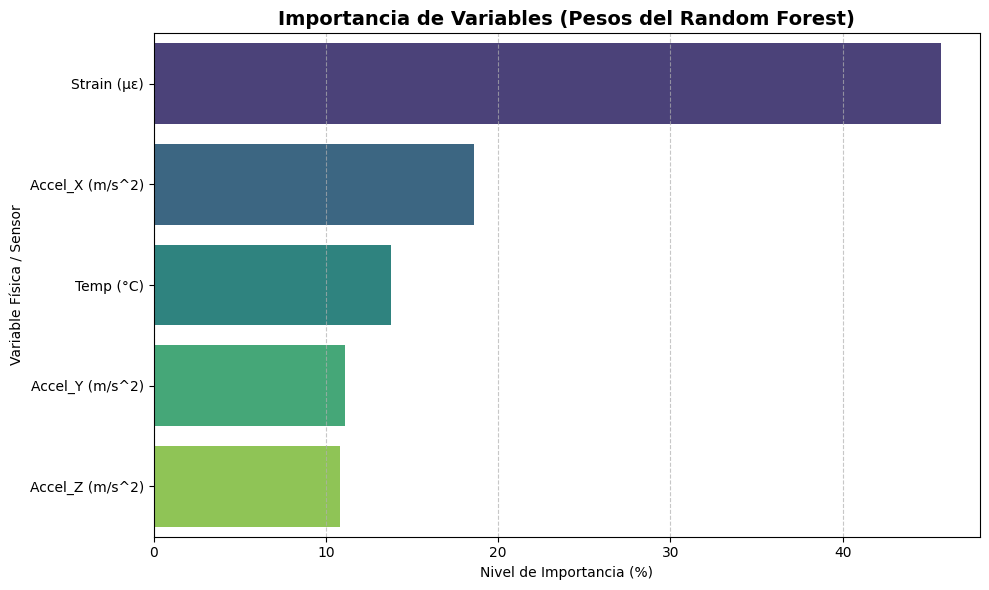

In [25]:
# 1. Extraemos los pesos calculados por el Random Forest
pesos = modelo_rf.feature_importances_

# 2. Creamos un nuevo DataFrame para verlo bonito y lo ordenamos de mayor a menor
importancias_df = pd.DataFrame({
    'Sensor': variables_sensores,
    'Peso (Importancia)': pesos * 100 # Lo pasamos a porcentaje
}).sort_values(by='Peso (Importancia)', ascending=False)

# 3. Mostramos la tabla exacta en texto
print("--- PESOS ASIGNADOS A CADA VARIABLE ---")
print(importancias_df.to_string(index=False))

# 4. Dibujamos el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso (Importancia)', y='Sensor', data=importancias_df, palette='viridis', hue='Sensor', legend=False)
# Estética del gráfico
plt.title('Importancia de Variables (Pesos del Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia (%)')
plt.ylabel('Variable Física / Sensor')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()